# Notebook Purpose

Analyze dataset coverage and candidate-set behavior to validate modeling design choices.


## Workflow

Setup, run, evaluate, and save outputs.


In [1]:
# Cell 1: Understanding the Instacart Task Definition

import pandas as pd
import numpy as np

print("="*60)
print("INSTACART DATASET STRUCTURE ANALYSIS")
print("="*60)

# Load data
train_df = pd.read_parquet('../data/processed/train_dataset.parquet')
val_df = pd.read_parquet('../data/processed/val_dataset.parquet')
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')

print("\n📊 Key Question: What are we predicting?")
print("-" * 60)

# Check: Are ALL products in train_df from user history?
print(f"\n1. All products in dataset are from user history:")
print(f"   Min up_times_bought: {train_df['up_times_bought'].min()}")
print(f"   → {train_df['up_times_bought'].min() > 0}")

# How many products per user?
products_per_user = train_df.groupby('user_id')['product_id'].nunique()
print(f"\n2. Products per user (candidates to rank):")
print(f"   Mean: {products_per_user.mean():.1f}")
print(f"   Median: {products_per_user.median():.0f}")
print(f"   Max: {products_per_user.max()}")

# Total products in catalog
total_products = len(products)
print(f"\n3. Total products in catalog: {total_products:,}")

# Coverage
avg_coverage = products_per_user.mean() / total_products
print(f"\n4. Average user covers {avg_coverage:.1%} of catalog")
print(f"   → We only rank {avg_coverage:.1%}, not 100%!")

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print("""
The Instacart competition task is NOT:
  ❌ Recommend from ALL 50K products
  
The task IS:
  ✅ Given user's purchase history (avg 65 products)
  ✅ Predict which ones they'll reorder
  
This means:
  → "Candidate generation" already done by dataset design
  → We only need a "ranker" (single-stage model)
  → Two-stage would be redundant for this task
  
In production (real Instacart with new products):
  → Would need candidate generation
  → Two-stage would make sense
""")


INSTACART DATASET STRUCTURE ANALYSIS

📊 Key Question: What are we predicting?
------------------------------------------------------------

1. All products in dataset are from user history:
   Min up_times_bought: 1
   → True

2. Products per user (candidates to rank):
   Mean: 64.6
   Median: 48
   Max: 726

3. Total products in catalog: 49,688

4. Average user covers 0.1% of catalog
   → We only rank 0.1%, not 100%!

CONCLUSION

The Instacart competition task is NOT:
  ❌ Recommend from ALL 50K products
  
The task IS:
  ✅ Given user's purchase history (avg 65 products)
  ✅ Predict which ones they'll reorder
  
This means:
  → "Candidate generation" already done by dataset design
  → We only need a "ranker" (single-stage model)
  → Two-stage would be redundant for this task
  
In production (real Instacart with new products):
  → Would need candidate generation
  → Two-stage would make sense



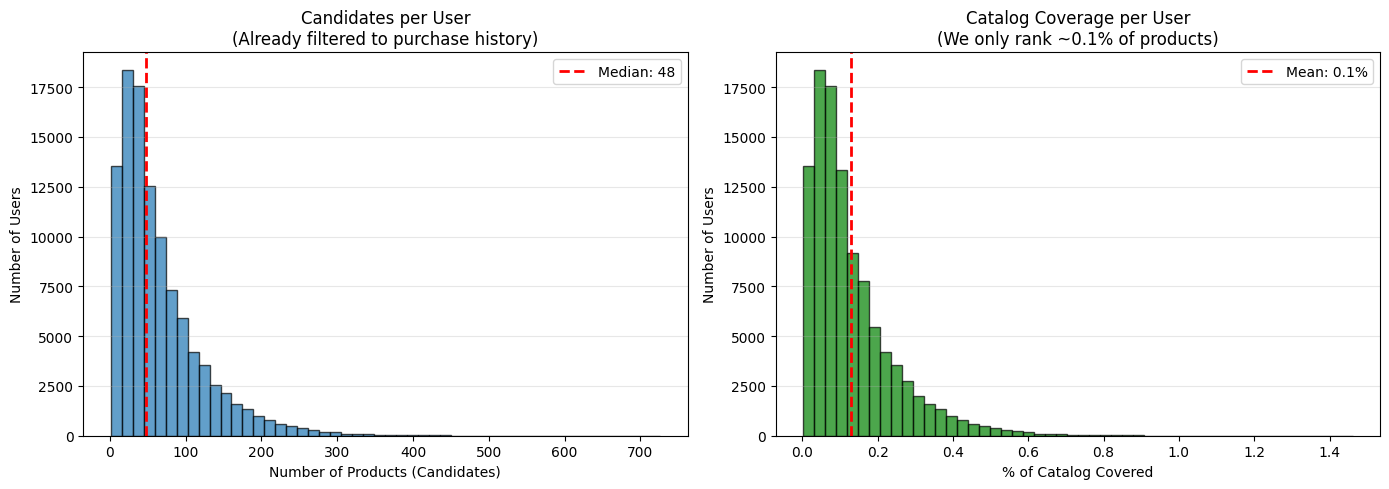

✅ Visualization saved: candidate_generation_analysis.png


In [2]:
# Cell 2: Visualize this

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution of products per user
axes[0].hist(products_per_user, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(products_per_user.median(), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {products_per_user.median():.0f}')
axes[0].set_xlabel('Number of Products (Candidates)')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Candidates per User\n(Already filtered to purchase history)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Coverage
coverage_pct = (products_per_user / total_products * 100).values
axes[1].hist(coverage_pct, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(coverage_pct.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {coverage_pct.mean():.1f}%')
axes[1].set_xlabel('% of Catalog Covered')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Catalog Coverage per User\n(We only rank ~0.1% of products)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/candidate_generation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: candidate_generation_analysis.png")
